Processing all samples with bbox generation + gaze mapping


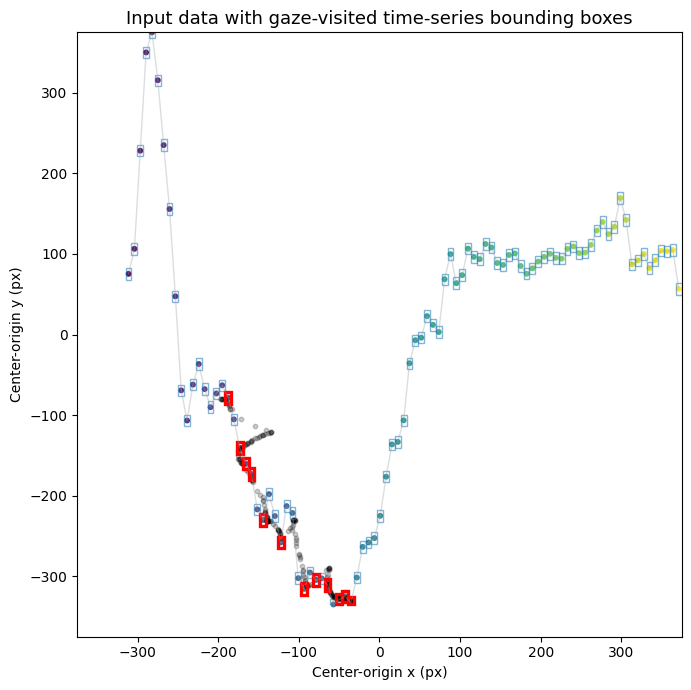

In [ ]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig
from tobii_pytracker.datasets.custom_dataset import TimeSeriesDataset
from tobii_pytracker.analyze.models import BBoxTimeSeriesAnalyzer

from pathlib import Path
import pandas as pd
from IPython.display import display


config = CustomConfig('./configs/config.yaml')
loader = DataLoader(config, root='./')
output_dir = Path("./analysis_outputs/text_demo")
output_dir.mkdir(parents=True, exist_ok=True)
print('Processing single sample with bbox generation + gaze mapping')

raw_sets = loader.get_all_data(flatten=False)
gaze_data = loader.get_all_data(flatten=True)


if gaze_data.empty:
    raise ValueError('No gaze samples found in any run.')

raw_data = pd.concat(raw_sets.values(), keys=raw_sets.keys(), names=['set_name','row_index']).reset_index(level='set_name').reset_index(drop=True)
raw_data['slide_index'] = raw_data.groupby('set_name').cumcount()


raw_data['set_name'] = raw_data['set_name'].astype(str)
gaze_data['set_name'] = gaze_data['set_name'].astype(str)
raw_data['slide_index'] = pd.to_numeric(raw_data['slide_index'], errors='coerce').astype('Int64')
gaze_data['slide_index'] = pd.to_numeric(gaze_data['slide_index'], errors='coerce').astype('Int64')

analyzer = BBoxTimeSeriesAnalyzer(output_folder=output_dir,config=config)
set_name = raw_data['set_name'].astype(str)[0]
slide_index =0
selected_gaze = gaze_data[(gaze_data['set_name'] == set_name) & (gaze_data['slide_index'] == slide_index)].copy()
results = analyzer.analyze(selected_gaze)
analyzer.plot_analysis(results)



Found 3 samples with gaze data

Processing sample 1/3: 20260915_121156, slide 0
  Gaze points: 253
  timeseries_bboxes: 95 bboxes


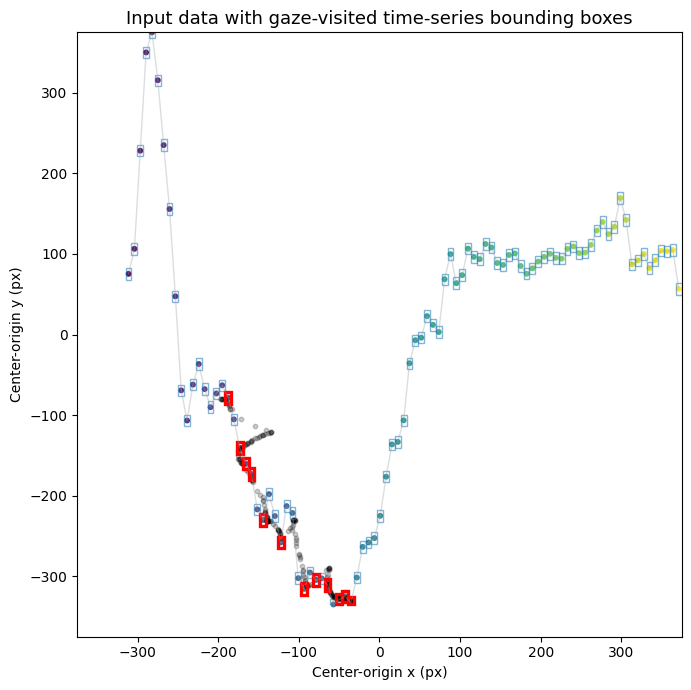


Processing sample 2/3: 20260915_121156, slide 1
  Gaze points: 163
  timeseries_bboxes: 95 bboxes


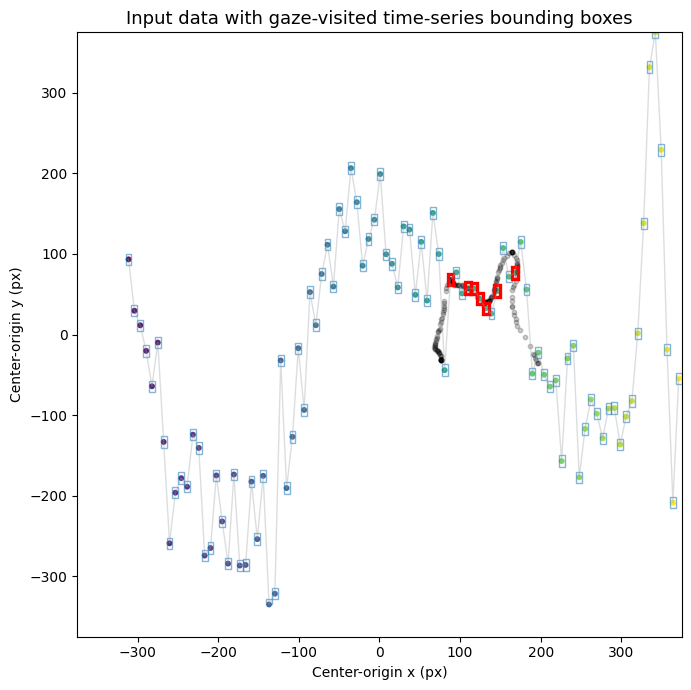


Processing sample 3/3: 20260915_121156, slide 2
  Gaze points: 227
  timeseries_bboxes: 95 bboxes


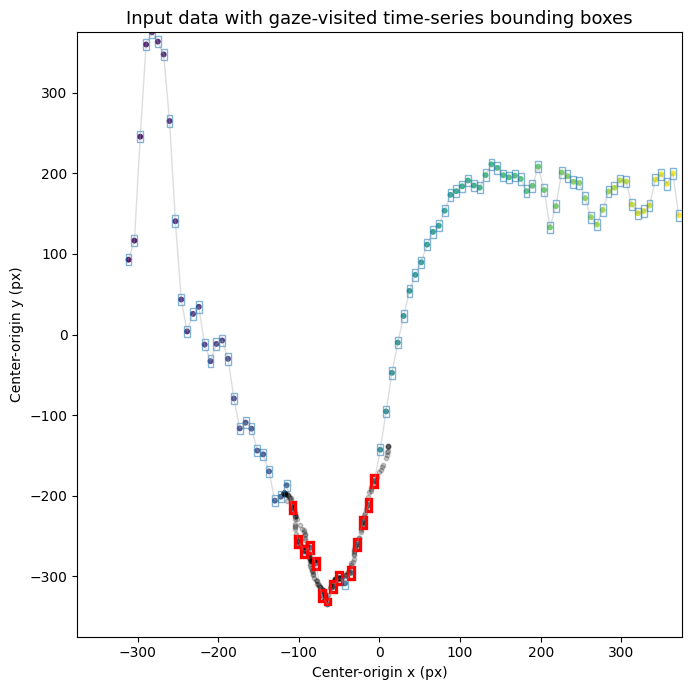


Done


In [2]:
import numpy as np
sets_with_gaze = set(gaze_data['set_name'].dropna().unique())
raw_data = raw_data[raw_data['set_name'].isin(sets_with_gaze)].copy()
gaze_data = gaze_data[gaze_data['set_name'].isin(sets_with_gaze)].copy()
if raw_data.empty:
    raise ValueError('No raw rows remain after filtering runs with gaze.')

gaze_counts = gaze_data.groupby(['set_name', 'slide_index']).size().rename('gaze_count').reset_index()
candidate_rows = raw_data.merge(gaze_counts, on=['set_name', 'slide_index'], how='inner')
candidate_rows = candidate_rows[candidate_rows['gaze_count'] > 0]
if candidate_rows.empty:
    raise ValueError('No slide with gaze points was found.')

print(f'Found {len(candidate_rows)} samples with gaze data')

output_dir = Path('./analysis_outputs/bbox_all_samples')
output_dir.mkdir(parents=True, exist_ok=True)
bbox_analyzer = BBoxTimeSeriesAnalyzer(output_folder=output_dir, config=config)
dataset = TimeSeriesDataset(config=config, calculate_bboxes=False)

all_comparison_rows = []

for idx, selected_raw in candidate_rows.iterrows():
    set_name = str(selected_raw['set_name'])
    slide_index = int(selected_raw['slide_index'])
    
    print(f'\nProcessing sample {idx + 1}/{len(candidate_rows)}: {set_name}, slide {slide_index}')
    
    selected_gaze = gaze_data[(gaze_data['set_name'] == set_name) & (gaze_data['slide_index'] == slide_index)].copy()
    if selected_gaze.empty:
        print(f'  WARNING: No gaze data found, skipping')
        continue


    print(f'  Gaze points: {len(selected_gaze)}')

    raw = np.fromstring(selected_raw["input_data"].strip("[]"), sep=" ")
    series2d = dataset._ensure_2d(raw)
    generated_by_method = {
        'timeseries_bboxes': dataset._compute_timeseries_bboxes_from_series(series2d),
    }

    for method, bboxes in generated_by_method.items():
        print(f'  {method}: {len(bboxes)} bboxes')

    sample_comparison_rows = []
    saved_plots = {}
    
    for method, method_bboxes in generated_by_method.items():
        method_raw = pd.DataFrame([selected_raw.to_dict()])
        method_raw['set_name'] = method_raw['set_name'].astype(str)
        method_raw['slide_index'] = pd.to_numeric(method_raw['slide_index'], errors='coerce').astype('Int64')
        method_raw.at[0, 'objects_bboxes'] = str({'timeseries_bboxes': method_bboxes})

        scores = bbox_analyzer.analyze(loader._flatten_gaze_data(method_raw,set_name=set_name))

        bbox_analyzer.plot_analysis(scores)

    if sample_comparison_rows:
        sample_comparison = pd.DataFrame(sample_comparison_rows)
        print(f'\n  Results for {set_name}, slide {slide_index}:')
        display(sample_comparison[['method', 'generated_bbox_count', 'total_gaze_points', 'bbox_hit_count', 'unique_gaze_hit_count', 'coverage_by_bboxes', 'overlap_factor', 'attended_bboxes', 'attended_bbox_ratio']].sort_values('coverage_by_bboxes', ascending=False))

if all_comparison_rows:
    print(f'Overall Summary across all {len(candidate_rows)} samples:')
    all_comparison = pd.DataFrame(all_comparison_rows)

    summary = all_comparison.groupby('method').agg({
        'generated_bbox_count': 'mean',
        'total_gaze_points': 'sum',
        'bbox_hit_count': 'sum',
        'unique_gaze_hit_count': 'sum',
        'coverage_by_bboxes': 'mean',
        'overlap_factor': 'mean',
        'attended_bboxes': 'mean',
        'attended_bbox_ratio': 'mean',
    }).reset_index()
    
    display(summary.sort_values('coverage_by_bboxes', ascending=False))
    
    print(f'\n✓ Processed {len(all_comparison_rows)} method-sample combinations')
    print(f'✓ Saved plots to: {output_dir}')
else:
    print('WARNING: No valid results were generated')

print('\nDone')